# Estimating Mutual Information from Data: a comparative analysis of existing methods.

References:
-  "A Statistical Framework for Neuroimaging data Analysis Based on Mutual Information Estimated via a Gaussian Copula"
- [Finite Sample bias correction (Miller-Madow) for Discrete Shannon Entropy](https://arxiv.org/abs/cond-mat/0403192)

Comments:

-   Some functions are written in Numba, a function compiler for accellerating Python code.
    If you do not have it installed, you can get it with:


    ```{bash}
    pip install numba
    ```


In [1]:
# ensures that if we change something in .core, it sees it imediately without having to restart the kernel
# every time you run a cell, all imported modules are reloaded auomatically
%load_ext autoreload
%autoreload 2 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap
import scipy
from kneed import KneeLocator

# Our package
import neuro_lib as nlib

# SETTING SEED FOR REPRODUCIBILITY
np.random.seed(0)

relations_dict = {"linear": lambda s: s,
                "tanh": lambda s: np.tanh(5*s),
                "quadratic": lambda s: 2 * s**2 - 1}

/Users/miriamzara/ITI_GroupProject/neuro_lib/analytics.py:20: SyntaxWarning: invalid escape sequence '\s'
  """


# **SIMULATED DATA**
1) Simulate an external signal $S(t)$ and a neural variable $X(t)$ with three different types of relation with or without lag. 

    Types: 
    - linear
    - monotonic non linear
    - non monotonic (quadratic for example)
 
2) Compute MI (with or without lag, and maybe conditioning on $X(t-1)$) with different methods. 
    
    Methods: 
    - Gaussian (assuming joint normality)
    - Binning 
    - KDE ** maybe ** 
    - Gaussian copula 


    **Gaussian channel**: 

$$
X = f(S) + \sigma \cdot \eta = Z + \sigma \cdot \eta
$$  

- Z: sent variable
- X: received variable
- $\eta$: gaussian white noise (mean = 0, std = 1)
- $\sigma$: channel noise amplitude

# No lag, no temporal structure: simplest case

We start simple. In this section we simulate data without temporal structure, meaning that the source variable $S(t)$ is identically independently distributed at each time step. At this stage, we just want to set up the code for estimating mi and compare the accuracy of the various estimators. 


We will benchmark various estimators with respect to the *true* value of the differential mutual information. Except for a few special cases, the true value is computed numerically. In order to simplify calculations, we assume that the source variable S is *gaussian*:

$$
S \sim \mathcal{N}(0, 1)
$$



**Ground truth mi calculation**:
--------------

Special case, **analytic**: linear relation $X = S + \sigma \cdot \eta$

$$
S \sim \mathcal{N}(m, v^2),\quad  \eta \sim \mathcal{N}(0, 1), \quad X = S + \sigma \cdot \eta
$$

$$
mi(X:S)= \frac{1}{2}\log_2\left( 1 + \frac{v^2}{\sigma^2}\right)
$$

--------------

General case, **numeric**: $X = f(S) + \sigma \cdot \eta$

$$
mi(X:S) = h(X) - h(X|S) = h(x) - \frac{1}{2}\log_2[2\pi e \sigma^2]
$$

To **approximate h(X)**:

1. generate a large number of X samples (e.g. $N = 1000$)
2. Use KDE to estimate the pdf of X, p
3. Approximate the expectation value with the sample mean $h(x) =\mathbb{E}[- \log_2(p(x))] \simeq - \frac{1}{N} \sum \log_2[p(x_i)]$



**Gaussian case: comparison of the analytical mi and the numeric mi (correctness check)**

entropy analytic: 2.547095585180641
entropy numeric: 2.556511804873843
mi analytic: 0.5
mi numeric: 0.5094162196932022


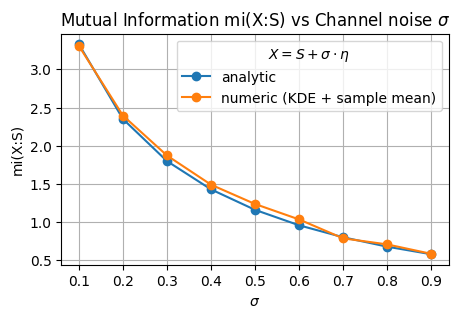

In [3]:
sigma_ = 1
numeric_hx = nlib.entropy_numeric(lambda s: s, sigma=sigma_)


print("entropy analytic:", nlib.entropy_gaussian(np.sqrt(sigma_**2 + 1)))
print("entropy numeric:", numeric_hx)


numeric_mi = numeric_hx - nlib.entropy_gaussian(sigma_)

print("mi analytic:", nlib.mi_gaussian_analytic(sigma_**2))
print("mi numeric:", numeric_mi)



sigma_vec = np.arange(0.1, 1, 0.1)
numeric_mi = [nlib.entropy_numeric(lambda s: s, sigma=sigma) - nlib.entropy_gaussian(sigma) for sigma in sigma_vec]
analytic_mi = [nlib.mi_gaussian_analytic(sigma**2) for sigma in sigma_vec]

fig ,ax = plt.subplots(figsize = (5, 3))
ax.plot(sigma_vec, analytic_mi, marker = "o",  label = "analytic")
ax.plot(sigma_vec, numeric_mi, marker = "o", label = "numeric (KDE + sample mean)")
ax.grid()
ax.legend(title = r"$X = S + \sigma \cdot \eta$")
ax.set_title(r"Mutual Information mi(X:S) vs Channel noise $\sigma$")
ax.set_xlabel(r"$\sigma$")
ax.set_ylabel("mi(X:S)")
plt.show()


Text(0, 0.5, 'mi(X:S)')

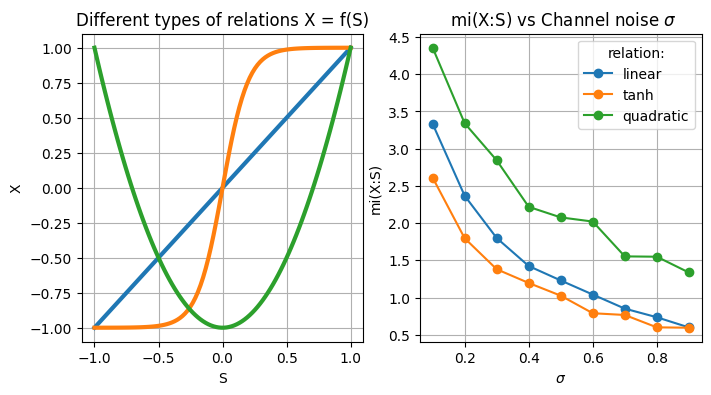

In [4]:
S = np.linspace(-1, +1, 100)

mi_trends = []
for key, f in relations_dict.items():
   mi_trends.append([nlib.entropy_numeric(f, sigma=sigma) - nlib.entropy_gaussian(sigma) for sigma in sigma_vec])

X = np.vstack([nlib.generate_neural_variable(S, f = relations_dict["linear"], noise_std = 0),
            nlib.generate_neural_variable(S, f = relations_dict["tanh"], noise_std = 0),
            nlib.generate_neural_variable(S, f = relations_dict["quadratic"], noise_std = 0)])


fig, axs = plt.subplots(nrows = 1, ncols = 2, figsize = (8, 4))

for i, key in enumerate(relations_dict.keys()):
    axs[0].plot(S, X[i, :], label = key, lw = 3)
    axs[1].plot(sigma_vec, mi_trends[i], marker = "o", label = key)

axs[0].set_xlabel("S")
axs[0].set_ylabel("X")
axs[0].set_title("Different types of relations X = f(S)")
axs[0].grid()

axs[1].grid()
axs[1].legend(title = "relation:")
axs[1].set_title(r" mi(X:S) vs Channel noise $\sigma$")
axs[1].set_xlabel(r"$\sigma$")
axs[1].set_ylabel("mi(X:S)")

**Examples of joint scatterplots**

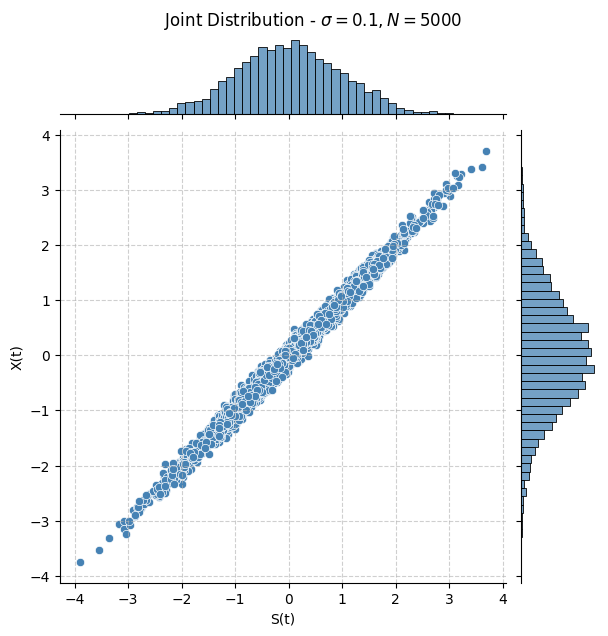

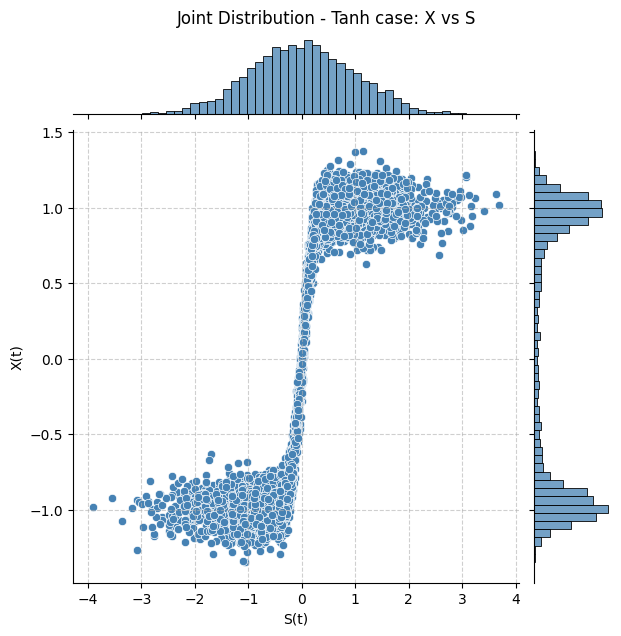

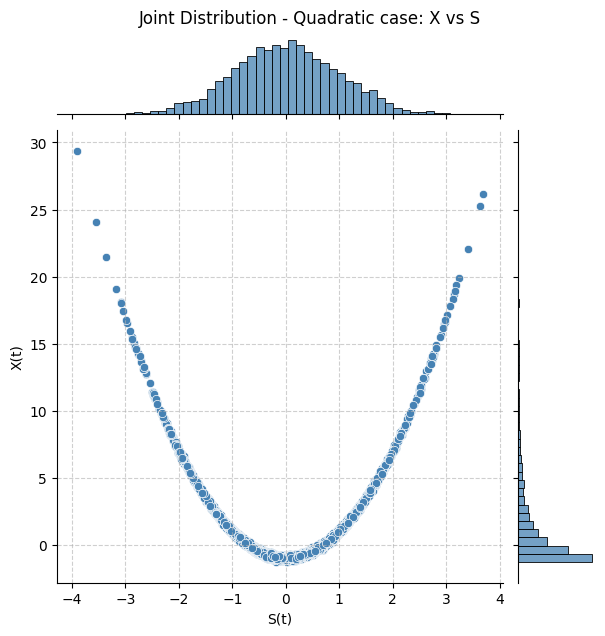

In [5]:
Ntsteps = 5000  # number of samples
sigma_ = 0.1    # channel noise
S = np.random.normal(0, 1, Ntsteps)

X_linear = nlib.generate_neural_variable(S, f= lambda s: s, noise_std = sigma_)
nlib.plot_joint_distribution_sns(S, X_linear, title_string = rf"$\sigma = {sigma_}, N = {Ntsteps}$")

X_tanh = nlib.generate_neural_variable(S, f= lambda s: np.tanh(5*s), noise_std = sigma_)
nlib.plot_joint_distribution_sns(S, X_tanh, title_string = "Tanh case: X vs S")

X_quad = nlib.generate_neural_variable(S, lambda s: 2*s**2 - 1, noise_std = sigma_)
nlib.plot_joint_distribution_sns(S, X_quad, title_string = "Quadratic case: X vs S")

## BINNING METHOD


If X, S are the continuous r.v.s and $X_\epsilon, S_\epsilon$ are their discretized (binned) versions,

$$
lim_{\epsilon \rightarrow 0^+} MI(X_{\epsilon}: S_{\epsilon}) = mi(X, S)
$$


Leaving aside the problem posed by the *curse of dimensionality*, the binning method has some challenges even in the simplest, 2d case:

1. **Bin Number choice**
    - too few bins -> the discretized MI is not a good approximation of the differential mi
    - too many bins -> we are fitting noise


    How do we understand if the bin choice is good, considered that, in practice, we usually have a single data sample, of fixed (possibly low) size?

2. **Uncertainty Estimation**
    Given that the estimate of mi contains dependence on the dataset, can we associate a measure of statistical uncertainty to it?

    A possibility is to do **bootstrapping**: 
    - draw $n<N$ samples from the dataset (with replacement)
    - estimate the mi
    - repeat for a large number of times
    - compute the empirical standard deviation

    But it is not really satisfactory

### Choosing the optimal number of bins

In [6]:
from neuro_lib.core import mi_binning_2d_numba, histogram_error_numba

In [ ]:
# ------ Linear case f(s)= s --------------
sigma_ = 0.1
ground_truth_mi = nlib.mi_gaussian_analytic(sigma_**2)
N = 1000
M = 10      # number of realizations

bins = np.arange(10, 500, 2)
db = bins[1] - bins[0]
results = np.empty(shape = (M, len(bins)))
bin_errors = np.empty(shape = (M, len(bins)))

for m in range(M):
    data = nlib.generate_data(N, sigma_)
    for idx, bin in enumerate(bins):
        results[m, idx] = mi_binning_2d_numba(data, bin, "miller")
        bin_errors[m, idx] = histogram_error_numba(data[:, 1], bin) # average poisson error for the histogram -  1/sqrt(conunts)
                                                                    # data[:, 1] is the response variable, X = f(S) + sigma * eta
avg_results = np.mean(results, axis = 0)
std_results = np.std(results, axis = 0)
avg_bin_errors = np.mean(bin_errors, axis = 0)

# x = number of bins, y = MI values
# S is sensitivity (try 1.0 or 2.0)
# curve='concave' because MI curves usually flatten out
# direction='increasing'


kn = KneeLocator(bins, avg_results, S=1.0, curve='concave', direction='increasing')

knee_idx = np.argwhere(bins == kn.knee)[0][0]
print(f"Optimal number of bins: {kn.knee, knee_idx}")
#kn.plot_knee()

Optimal number of bins: (58, 24)


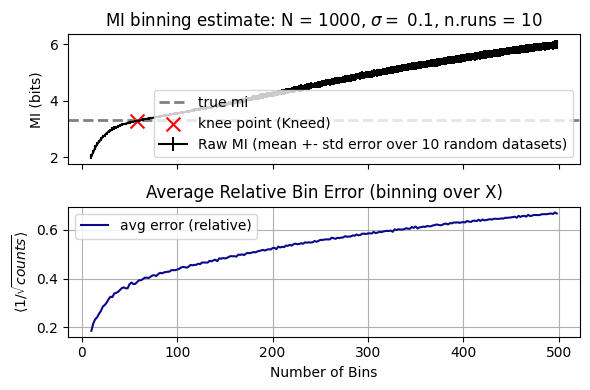

In [11]:
colors = cm.plasma(np.linspace(0, 0.8, 2))
color_dict = {
    "dy": colors[0],
    "d2y": colors[1]
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 4), sharex=True)

ax1.axhline(ground_truth_mi, label = "true mi", color = "grey", linestyle = "dashed", linewidth = 2)
ax1.errorbar(bins, avg_results, std_results, color = "black", label=f'Raw MI (mean +- std error over {M} random datasets)')
ax1.plot()

ax1.scatter(bins[knee_idx], avg_results[knee_idx], marker = "x", color = "red", s = 100, label = "knee point (Kneed)")

ax1.set_ylabel('MI (bits)')
ax1.set_title(fr"MI binning estimate: N = {N}, $\sigma=$ {sigma_}, n.runs = {M}")
ax1.legend()


# Bottom plot: Average bin count Errors
ax2.plot(bins, avg_bin_errors, '-',color=color_dict["dy"], label='avg error (relative)')
ax2.set_ylabel(r'$\langle1/\sqrt{counts}\rangle$')
ax2.set_xlabel('Number of Bins')
ax2.set_title('Average Relative Bin Error (binning over X)')
ax2.grid()
ax2.legend()

plt.tight_layout()
plt.savefig(f"figures/mi_binning_N_{N}_sigma_{sigma_}.pdf")
plt.show()

*Empirical observation*: the true value of m.i. seems to corresponds to a knee point of the mi estimate obtained through binning -> This could be a possible cryterion for choosing the optimal bin number.

Let us now systematically check how this cryterion performs, at varying sample size (N) and channel noise ($\sigma$).

But what happens if no knee is found? When knee detection fails, we select a fallback number of bins proportional to $2\sqrt{N}$, a commonly used heuristic in histogram estimation. The closest value within the predefined bin grid is used. While not optimal, this ensures numerical stability and a reasonable bias–variance trade-off.

In [12]:
sigma_vec = np.array([0.1, 0.2, 0.4, 0.6, 0.8, 1.])
N_vec = np.array([100, 200, 500, 1000, 2000, 5000])
M = 10

estimates = np.empty(shape = (len(sigma_vec), len(N_vec), M))
true_mi_vec = np.array([nlib.mi_gaussian_analytic(s**2) for s in sigma_vec])


for i, sigma in enumerate(sigma_vec):
    for j, N in enumerate(N_vec):

        dynamic_max = max(int(2 * np.sqrt(N)) , 50)
        step = 2
        bins = np.arange(10, dynamic_max, step)
        
        for k in range(M):
            data = nlib.generate_data(N, sigma)
            estimates[i, j, k] = nlib.estimate_mi(data, method = "binning", bins = bins)


avg_estimates = np.mean(estimates, axis=2)
relative_errors = np.abs((avg_estimates - true_mi_vec[:, np.newaxis]) / true_mi_vec[:, np.newaxis])

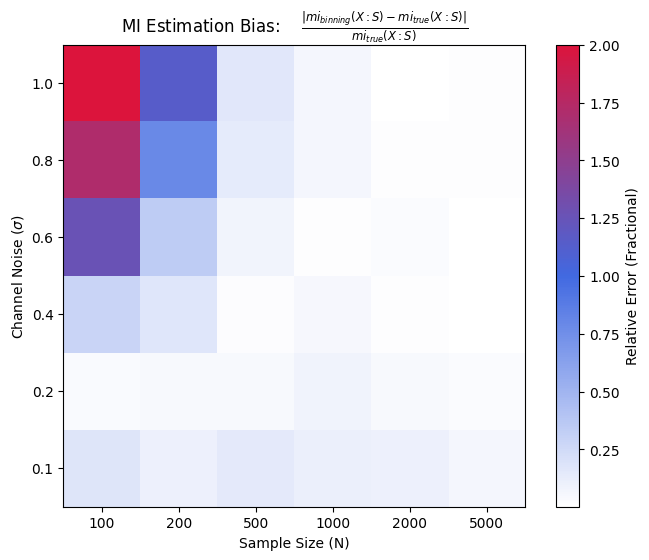

In [14]:
colors = ["white", "royalblue", "crimson"] 
nodes = [0.0, 0.5, 1.0]
my_cmap = LinearSegmentedColormap.from_list("my_custom_scale", list(zip(nodes, colors)))
my_cmap.set_bad(color = "black")

fig, ax = plt.subplots(figsize=(8, 6))

relative_errors_clipped = np.clip(relative_errors, a_min = 0, a_max = 2)
im = ax.imshow(relative_errors_clipped, cmap=my_cmap, origin = "lower")
cbar = fig.colorbar(im)
cbar.set_label('Relative Error (Fractional)')

ax.set_xticks(np.arange(len(N_vec)))
ax.set_xticklabels(N_vec)
ax.set_yticks(np.arange(len(sigma_vec)))
ax.set_yticklabels(sigma_vec)

ax.set_xlabel("Sample Size (N)")
ax.set_ylabel(r"Channel Noise ($\sigma$)")
ax.set_title(r"MI Estimation Bias: $\quad \frac{|mi_{binning}(X:S) - mi_{true}(X:S)|}{mi_{true}(X:S)}$")

plt.show()

Works pretty well... but will it work also for other kind of relationships f(S)?

Optimal number of bins: (52, 21)


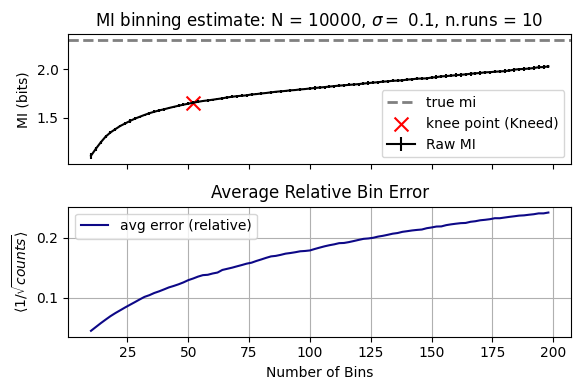

In [15]:
# ---- Function: tanh -----------
f = relations_dict["tanh"]

sigma_ = 0.1
ground_truth_mi = nlib.mi_numeric(f, N_large = 10000, sigma = sigma_)

N = 10000
M = 10

bins = np.arange(10, 200, 2)
db = bins[1] - bins[0]
results = np.empty(shape = (M, len(bins)))
bin_errors = np.empty(shape = (M, len(bins)))

for m in range(M):
    data = nlib.generate_data(N, sigma_, f)
    for idx, bin in enumerate(bins):
        results[m, idx] = mi_binning_2d_numba(data, bin, "miller")
        bin_errors[m, idx] = histogram_error_numba(data[:, 1], bin)


avg_results = np.mean(results, axis = 0)
std_results = np.std(results, axis = 0)
avg_bin_errors = np.mean(bin_errors, axis = 0)



# x = number of bins, y = MI values
# S is sensitivity (try 1.0 or 2.0)
# curve='concave' because MI curves usually flatten out
# direction='increasing'
kn = KneeLocator(bins, avg_results, S=1.0, curve='concave', direction='increasing')

knee_idx = np.argwhere(bins == kn.knee)[0][0]
print(f"Optimal number of bins: {kn.knee, knee_idx}")

#kn.plot_knee()



colors = cm.plasma(np.linspace(0, 0.8, 2))
color_dict = {
    "dy": colors[0],
    "d2y": colors[1]
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 4), sharex=True)

ax1.axhline(ground_truth_mi, label = "true mi", color = "grey", linestyle = "dashed", linewidth = 2)
ax1.errorbar(bins, avg_results, std_results, color = "black", label='Raw MI')
ax1.plot()

ax1.scatter(bins[knee_idx], avg_results[knee_idx], marker = "x", color = "red", s = 100, label = "knee point (Kneed)")

ax1.set_ylabel('MI (bits)')
ax1.set_title(fr"MI binning estimate: N = {N}, $\sigma=$ {sigma_}, n.runs = {M}")
ax1.legend()


# Bottom plot: Average bin count Errors
ax2.plot(bins, avg_bin_errors, '-',color=color_dict["dy"], label='avg error (relative)')
ax2.set_ylabel(r'$\langle1/\sqrt{counts}\rangle$')
ax2.set_xlabel('Number of Bins')
ax2.set_title('Average Relative Bin Error')
ax2.grid()
ax2.legend()

plt.tight_layout()
plt.savefig(f"figures/mi_binning_N_{N}_sigma_{sigma_}.pdf")
plt.show()

Not really... there is no evident knee point in this curve, and whatever the number of bins, we are underestimating. For the linear case, we got a good estimate of mi when the average bin error was about $\sim 0.4$. Here it is smaller. Maybe we can try with more bins.

Optimal number of bins: (100, 0)


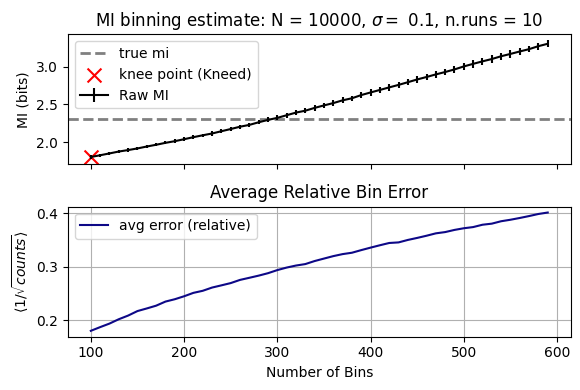

In [18]:
# ---- Function: tanh -----------
f = relations_dict["tanh"]

sigma_ = 0.1
ground_truth_mi = nlib.mi_numeric(f, N_large = 10000, sigma = sigma_)

N = 10000
M = 10

bins = np.arange(100, 600, 10)
db = bins[1] - bins[0]
results = np.empty(shape = (M, len(bins)))
bin_errors = np.empty(shape = (M, len(bins)))

for m in range(M):
    data = nlib.generate_data(N, sigma_, f)
    for idx, bin in enumerate(bins):
        results[m, idx] = mi_binning_2d_numba(data, bin, "miller")
        bin_errors[m, idx] = histogram_error_numba(data[:, 1], bin)


avg_results = np.mean(results, axis = 0)
std_results = np.std(results, axis = 0)
avg_bin_errors = np.mean(bin_errors, axis = 0)



# x = number of bins, y = MI values
# S is sensitivity (try 1.0 or 2.0)
# curve='concave' because MI curves usually flatten out
# direction='increasing'
kn = KneeLocator(bins, avg_results, S=1.0, curve='concave', direction='increasing')

knee_idx = np.argwhere(bins == kn.knee)[0][0]
print(f"Optimal number of bins: {kn.knee, knee_idx}")

#kn.plot_knee()



colors = cm.plasma(np.linspace(0, 0.8, 2))
color_dict = {
    "dy": colors[0],
    "d2y": colors[1]
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 4), sharex=True)

ax1.axhline(ground_truth_mi, label = "true mi", color = "grey", linestyle = "dashed", linewidth = 2)
ax1.errorbar(bins, avg_results, std_results, color = "black", label='Raw MI')
ax1.plot()

ax1.scatter(bins[knee_idx], avg_results[knee_idx], marker = "x", color = "red", s = 100, label = "knee point (Kneed)")

ax1.set_ylabel('MI (bits)')
ax1.set_title(fr"MI binning estimate: N = {N}, $\sigma=$ {sigma_}, n.runs = {M}")
ax1.legend()


# Bottom plot: Average bin count Errors
ax2.plot(bins, avg_bin_errors, '-',color=color_dict["dy"], label='avg error (relative)')
ax2.set_ylabel(r'$\langle1/\sqrt{counts}\rangle$')
ax2.set_xlabel('Number of Bins')
ax2.set_title('Average Relative Bin Error')
ax2.grid()
ax2.legend()

plt.tight_layout()
plt.savefig(f"figures/mi_binning_N_{N}_sigma_{sigma_}.pdf")
plt.show()

It doesnt help much. Now the raw MI line crosses the true mi value, but still there is no evident knee point so our detection method fails. How could we undestand which number of bin to choose? The curve shows no hint.

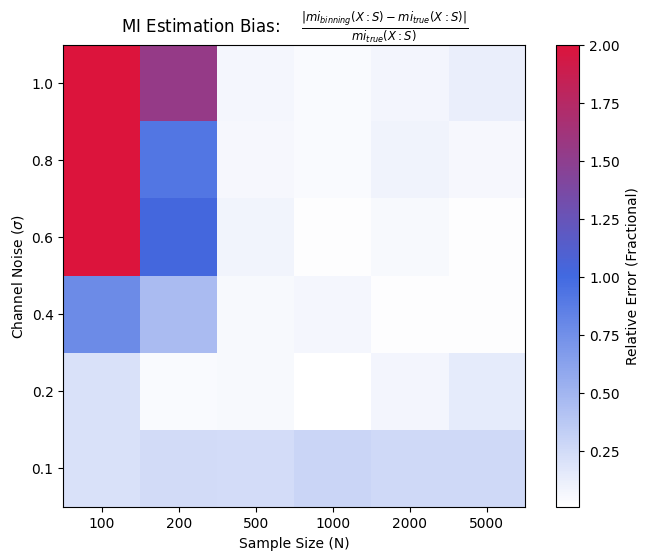

In [19]:
f = relations_dict["tanh"]

sigma_vec = np.array([0.1, 0.2, 0.4, 0.6, 0.8, 1.])
N_vec = np.array([100, 200, 500, 1000, 2000, 5000])
M = 10

estimates = np.empty(shape = (len(sigma_vec), len(N_vec), M))
true_mi_vec = np.array([nlib.mi_numeric(f, N_large = 10000, sigma = s) for s in sigma_vec])

# ---------------
for i, sigma in enumerate(sigma_vec):
    for j, N in enumerate(N_vec):

        dynamic_max = max(int(2 * np.sqrt(N)) , 50)
        step = 2
        bins = np.arange(10, dynamic_max, step)
        
        for k in range(M):
            data = nlib.generate_data(N, sigma, f)
            estimates[i, j, k] = nlib.estimate_mi(data, method = "binning", bins = bins)
            


avg_estimates = np.mean(estimates, axis=2)
relative_errors = np.abs((avg_estimates - true_mi_vec[:, np.newaxis]) / true_mi_vec[:, np.newaxis])


colors = ["white", "royalblue", "crimson"] 
nodes = [0.0, 0.5, 1.0]
my_cmap = LinearSegmentedColormap.from_list("my_custom_scale", list(zip(nodes, colors)))
my_cmap.set_bad(color = "black")



fig, ax = plt.subplots(figsize=(8, 6))

relative_errors_clipped = np.clip(relative_errors, a_min = 0, a_max = 2)
im = ax.imshow(relative_errors_clipped, cmap=my_cmap, origin = "lower")
cbar = fig.colorbar(im)
cbar.set_label('Relative Error (Fractional)')

ax.set_xticks(np.arange(len(N_vec)))
ax.set_xticklabels(N_vec)
ax.set_yticks(np.arange(len(sigma_vec)))
ax.set_yticklabels(sigma_vec)

ax.set_xlabel("Sample Size (N)")
ax.set_ylabel(r"Channel Noise ($\sigma$)")
ax.set_title(r"MI Estimation Bias: $\quad \frac{|mi_{binning}(X:S) - mi_{true}(X:S)|}{mi_{true}(X:S)}$")

plt.show()

Seems that when the channel noise gets higher than the $\sigma = 0.1$  we tried above, things eventually get better. Lets check visually how one of the curves where the method works look like.

Optimal number of bins: (18, 4)


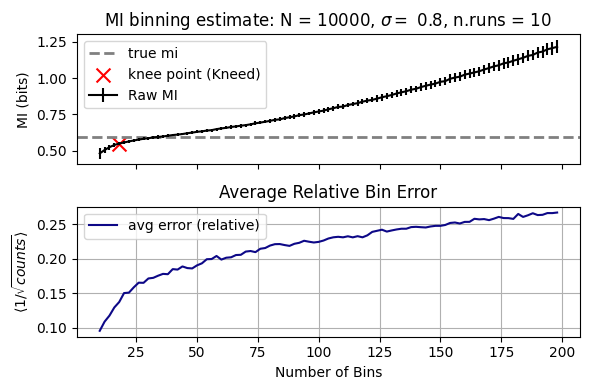

In [22]:
# ---- Function: tanh -----------
f = relations_dict["tanh"]

sigma_ = 0.8
ground_truth_mi = nlib.mi_numeric(f, N_large = 10000, sigma = sigma_)

N = 10000
M = 10

bins = np.arange(10, 200, 2)
db = bins[1] - bins[0]
results = np.empty(shape = (M, len(bins)))
bin_errors = np.empty(shape = (M, len(bins)))

for m in range(M):
    data = nlib.generate_data(N, sigma_, f)
    for idx, bin in enumerate(bins):
        results[m, idx] = mi_binning_2d_numba(data, bin, "miller")
        bin_errors[m, idx] = histogram_error_numba(data[:, 1], bin)


avg_results = np.mean(results, axis = 0)
std_results = np.std(results, axis = 0)
avg_bin_errors = np.mean(bin_errors, axis = 0)



# x = number of bins, y = MI values
# S is sensitivity (try 1.0 or 2.0)
# curve='concave' because MI curves usually flatten out
# direction='increasing'
kn = KneeLocator(bins, avg_results, S=1.0, curve='concave', direction='increasing')

knee_idx = np.argwhere(bins == kn.knee)[0][0]
print(f"Optimal number of bins: {kn.knee, knee_idx}")

#kn.plot_knee()



colors = cm.plasma(np.linspace(0, 0.8, 2))
color_dict = {
    "dy": colors[0],
    "d2y": colors[1]
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 4), sharex=True)

ax1.axhline(ground_truth_mi, label = "true mi", color = "grey", linestyle = "dashed", linewidth = 2)
ax1.errorbar(bins, avg_results, std_results, color = "black", label='Raw MI')
ax1.plot()

ax1.scatter(bins[knee_idx], avg_results[knee_idx], marker = "x", color = "red", s = 100, label = "knee point (Kneed)")

ax1.set_ylabel('MI (bits)')
ax1.set_title(fr"MI binning estimate: N = {N}, $\sigma=$ {sigma_}, n.runs = {M}")
ax1.legend()


# Bottom plot: Average bin count Errors
ax2.plot(bins, avg_bin_errors, '-',color=color_dict["dy"], label='avg error (relative)')
ax2.set_ylabel(r'$\langle1/\sqrt{counts}\rangle$')
ax2.set_xlabel('Number of Bins')
ax2.set_title('Average Relative Bin Error')
ax2.grid()
ax2.legend()

plt.tight_layout()
plt.savefig(f"figures/mi_binning_N_{N}_sigma_{sigma_}.pdf")
plt.show()

There is a more visible change of curvature indeed.

---

## GAUSSIAN METHOD


We consider a simple estimator based on the assumption that the joint distribution of the variables is Gaussian.

Under this assumption, mutual information depends only on the Pearson correlation coefficient $\rho$:

$$
I(X;S) = -\frac{1}{2} \log_2(1 - \rho^2)
$$

This estimator is extremely simple and computationally efficient, as it only requires estimating the correlation between variables.

---

### Linear Case

In the linear setting $X = S + \sigma \eta$, the joint distribution is Gaussian. Therefore, the Gaussian estimator is expected to be optimal.



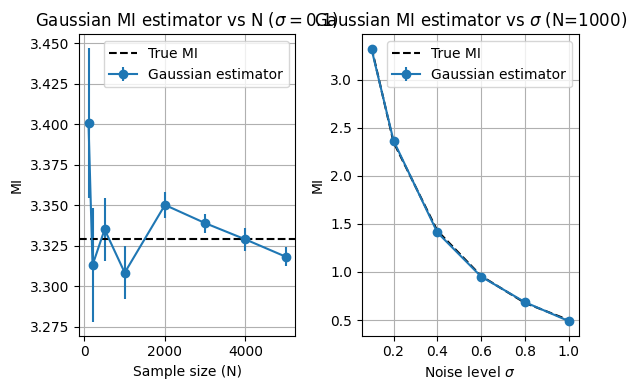

In [25]:

sigma_val = 0.1
N_vec = np.array([100, 200, 500, 1000, 2000, 3000, 4000, 5000])
M = 10
N_fixed = 1000
sigma_vec = np.array([0.1, 0.2, 0.4, 0.6, 0.8, 1.0])


true_mi_N = nlib.mi_gaussian_analytic(sigma_val**2)
gauss_estimates_N = np.zeros((len(N_vec), M))

for i, N in enumerate(N_vec):
    for m in range(M):
        data = nlib.generate_data(N, sigma_val)
        gauss_estimates_N[i, m] = nlib.estimate_mi(data, method="gauss")

mean_gauss_N = np.mean(gauss_estimates_N, axis=1)
std_error_N = np.std(gauss_estimates_N, axis=1) / np.sqrt(M)


gauss_estimates_sig = np.zeros((len(sigma_vec), M))
true_mi_sig = np.array([nlib.mi_gaussian_analytic(s**2) for s in sigma_vec])

for i, sigma in enumerate(sigma_vec):
    for m in range(M):
        data = nlib.generate_data(N_fixed, sigma)
        gauss_estimates_sig[i, m] = nlib.estimate_mi(data, method="gauss")

mean_gauss_sig = np.mean(gauss_estimates_sig, axis=1)
std_error_sig = np.std(gauss_estimates_sig, axis=1) / np.sqrt(M)

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 4))

# Subplot 1: MI vs N
ax1.errorbar(N_vec, mean_gauss_N, yerr=std_error_N, marker='o', label="Gaussian estimator")
ax1.axhline(true_mi_N, linestyle='dashed', color='black', label="True MI")
ax1.set_xlabel("Sample size (N)")
ax1.set_ylabel("MI")
ax1.set_title(rf"Gaussian MI estimator vs N ($\sigma={sigma_val}$)")
ax1.legend()
ax1.grid(True)

# Subplot 2: MI vs Sigma
ax2.errorbar(sigma_vec, mean_gauss_sig, yerr=std_error_sig, marker='o', label="Gaussian estimator")
ax2.plot(sigma_vec, true_mi_sig, linestyle='dashed', color='black', label="True MI")
ax2.set_xlabel(r"Noise level $\sigma$")
ax2.set_ylabel("MI")
ax2.set_title(rf"Gaussian MI estimator vs $\sigma$ (N={N_fixed})")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

Our results confirm that:
- The estimator is unbiased
- Variance decreases with increasing sample size
- It closely matches the analytical mutual information

---

### Nonlinear Settings

However, when the relationship between variables is nonlinear (e.g., $ = \tanh(S) + \sigma \eta$), the joint distribution is no longer Gaussian. Actually, it is not even slightly similar to a gaussian.

In this case:
- The Gaussian estimator only captures linear dependence
- Mutual information is therefore systematically underestimated

This highlights a key limitation: while efficient, the Gaussian estimator fails whenever dependencies are not fully described by correlation.

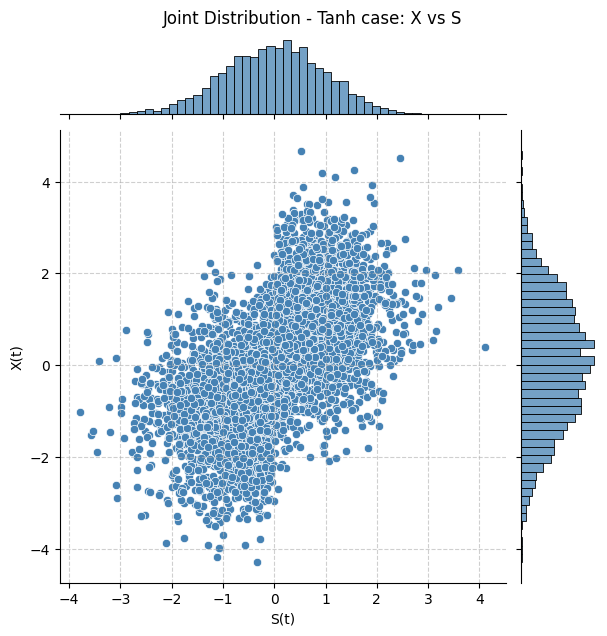

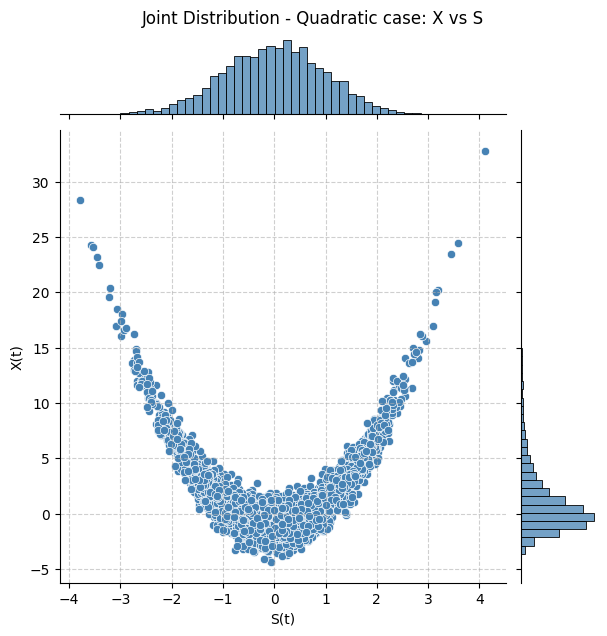

In [27]:
Ntsteps = 5000  # number of samples
sigma_ = 1    # channel noise
S = np.random.normal(0, 1, Ntsteps)

X_tanh = nlib.generate_neural_variable(S, f= lambda s: np.tanh(5*s), noise_std = sigma_)
nlib.plot_joint_distribution_sns(S, X_tanh, title_string = "Tanh case: X vs S")

X_quad = nlib.generate_neural_variable(S, lambda s: 2*s**2 - 1, noise_std = sigma_)
nlib.plot_joint_distribution_sns(S, X_quad, title_string = "Quadratic case: X vs S")

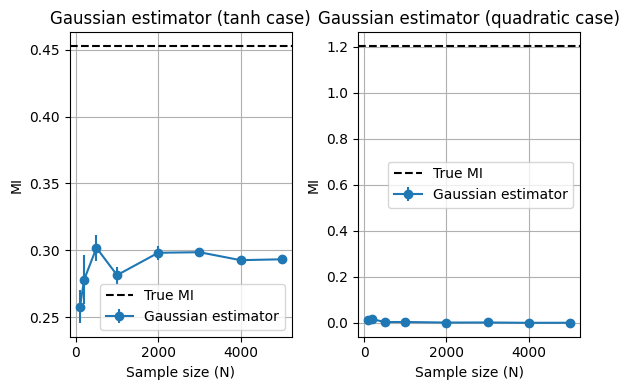

In [31]:
N_vec = np.array([100, 200, 500, 1000, 2000, 3000, 4000, 5000])
M = 10
sigma_ = 1


f_tanh = relations_dict["tanh"]
true_mi_tanh = nlib.mi_numeric(f_tanh, N_large=10000, sigma=sigma_)
gauss_tanh = np.zeros((len(N_vec), M))

for i, N in enumerate(N_vec):
    for m in range(M):
        data = nlib.generate_data(N, sigma_, f=f_tanh)
        gauss_tanh[i, m] = nlib.estimate_mi(data, method="gauss")

mean_tanh = np.mean(gauss_tanh, axis=1)
err_tanh = np.std(gauss_tanh, axis=1) / np.sqrt(M)



f_quad = relations_dict["quadratic"]
true_mi_quad = nlib.mi_numeric(f_quad, N_large=10000, sigma=sigma_)
gauss_quad = np.zeros((len(N_vec), M))

for i, N in enumerate(N_vec):
    for m in range(M):
        data = nlib.generate_data(N, sigma_, f=f_quad)
        gauss_quad[i, m] = nlib.estimate_mi(data, method="gauss")

mean_quad = np.mean(gauss_quad, axis=1)
err_quad = np.std(gauss_quad, axis=1) / np.sqrt(M)

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 4))


ax1.errorbar(N_vec, mean_tanh, yerr=err_tanh, marker='o', label="Gaussian estimator")
ax1.axhline(true_mi_tanh, linestyle='dashed', color='black', label="True MI")
ax1.set_xlabel("Sample size (N)")
ax1.set_ylabel("MI")
ax1.set_title("Gaussian estimator (tanh case)")
ax1.legend()
ax1.grid(True)


ax2.errorbar(N_vec, mean_quad, yerr=err_quad, marker='o', label="Gaussian estimator")
ax2.axhline(true_mi_quad, linestyle='dashed', color='black', label="True MI")
ax2.set_xlabel("Sample size (N)")
ax2.set_ylabel("MI")
ax2.set_title("Gaussian estimator (quadratic case)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

---

## KDE METHOD
Now let's change method to something that has much more potential to work. Given that the differential mutual information can be written as:

$$
mi(X:S) = \int \,dx\,ds \,\log_2{\left[\frac{f(s, x)}{f(s)\cdot f(x)}\right]}  \cdot f(s, x) \equiv \mathbb{E}[\log_2{\left[\frac{f(s, x)}{f(s)\cdot f(x)}\right]}]
$$
We could use KDE to estimate the (joint, marginal) pdfs, and then approximate shannon entropy with the sample mean
$$
mi(X:S) = \mathbb{E}[\log_2{\left[\frac{f(s, x)}{f(s)\cdot f(x)}\right]}] \simeq \frac{1}{N}\, \sum_i \log_2\left[\frac{f(s_i, x_i)}{f(s_i)\cdot f(x_i)}\right]
$$

In [54]:
# --- Linear case ---
N = 1000
sigma_ = 0.1
data = nlib.generate_data(N, sigma_)
true_mi = nlib.mi_gaussian_analytic(sigma_**2)

print("Analytical MI:" , true_mi)
print("KDE estimated MI:" , nlib.estimate_mi(data, method = "kde"))

Analytical MI: 3.3291057413758973
KDE estimated MI: 3.400826334137401


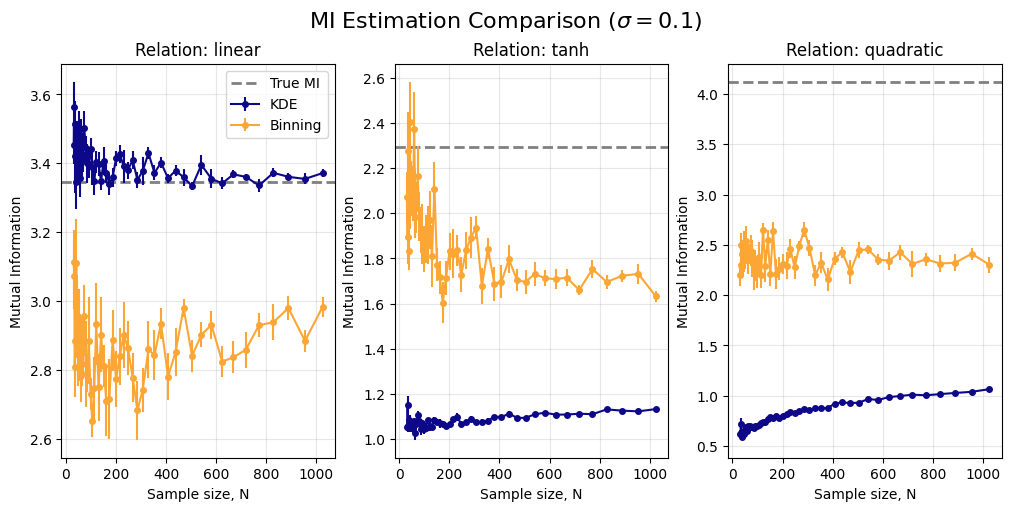

In [41]:
import os

os.makedirs("Data/", exist_ok=True)

def run_mi_comparison(f_func, label_name, sigma=0.1, M=10, save_name="Data/mi_results.npz"):
    """
    Runs MI estimation for a given function f and returns the stats for plotting.
    """
    N_vec = np.floor(np.logspace(5, 10, base=2)).astype(int)
    true_mi = nlib.mi_numeric(f_func, N_large=10000, sigma=sigma)

    binning_estimates = np.empty(shape=(len(N_vec), M))
    kde_estimates = np.empty(shape=(len(N_vec), M))

    for i, N in enumerate(N_vec):
        for realization in range(M):
            data = nlib.generate_data(N, sigma, f=f_func)
            kde_estimates[i, realization] = nlib.estimate_mi(data, method="kde")
            
            dynamic_max = max(int(2 * np.sqrt(N)), 50)
            bins = np.arange(10, dynamic_max, 2)
            binning_estimates[i, realization] = nlib.estimate_mi(data, method="binning", bins=bins)


    np.savez(save_name, N_vec=N_vec, kde=kde_estimates, binning=binning_estimates, true_mi=true_mi)
    
    return {
        "N_vec": N_vec,
        "true_mi": true_mi,
        "mean_kde": np.mean(kde_estimates, axis=1),
        "std_err_kde": np.std(kde_estimates, axis=1) / np.sqrt(M),
        "mean_binning": np.mean(binning_estimates, axis=1),
        "std_err_binning": np.std(binning_estimates, axis=1) / np.sqrt(M)
    }









# --- Setup for Multi-axis Plotting ---
sigma_ = 0.1
num_plots = len(relations_dict)
cols = 3
rows = (num_plots + 1) // cols  # Adjusts rows based on dictionary size

fig, axes = plt.subplots(rows, cols, figsize=(10, 5 * rows), constrained_layout=True)
axes = axes.flatten() # Flatten to 1D for easy indexing
colors = cm.plasma(np.linspace(0, 0.8, 2))



for i, (name, f) in enumerate(relations_dict.items()):
    ax = axes[i]
    

    results = run_mi_comparison(f, name, sigma=sigma_, 
                                save_name=f"Data/{name}_sigma_{sigma_}_results.npz")
    

    ax.axhline(results["true_mi"], color="grey", linestyle="dashed", linewidth=2, label="True MI")
    ax.errorbar(results["N_vec"], results["mean_kde"], results["std_err_kde"], 
                color=colors[0], marker="o", markersize=4, label="KDE")
    ax.errorbar(results["N_vec"], results["mean_binning"], results["std_err_binning"], 
                color=colors[1], marker="o", markersize=4, label="Binning")

    ax.set_title(f"Relation: {name}")
    ax.set_xlabel("Sample size, N")
    ax.set_ylabel("Mutual Information")
    ax.grid(True, alpha=0.3)
    if i == 0: 
        ax.legend()


for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(fr"MI Estimation Comparison ($\sigma={sigma_}$)", fontsize=16)
plt.show()

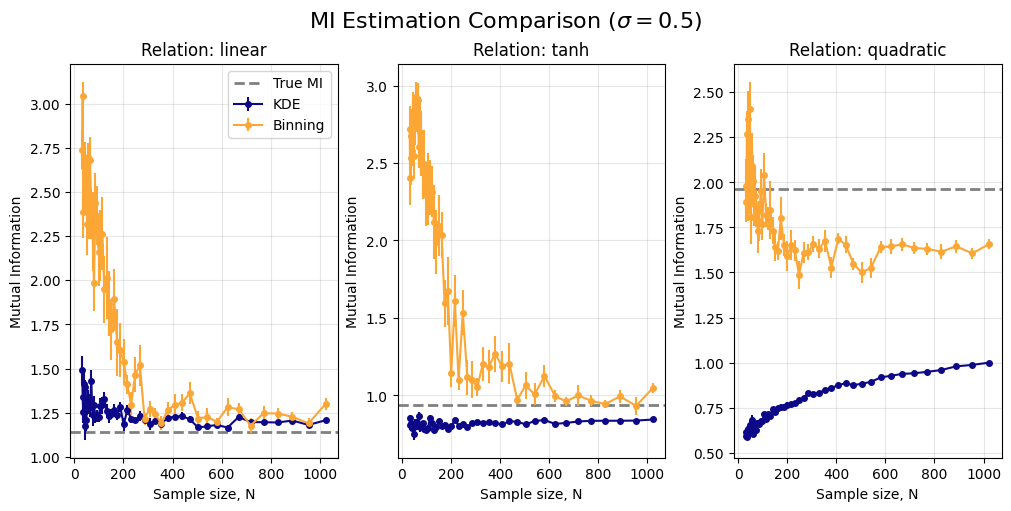

In [42]:

sigma_ = 0.5
num_plots = len(relations_dict)
cols = 3
rows = (num_plots + 1) // cols 
fig, axes = plt.subplots(rows, cols, figsize=(10, 5 * rows), constrained_layout=True)
axes = axes.flatten() # Flatten to 1D for easy indexing
colors = cm.plasma(np.linspace(0, 0.8, 2))



for i, (name, f) in enumerate(relations_dict.items()):
    ax = axes[i]
    

    results = run_mi_comparison(f, name, sigma=sigma_, 
                                save_name=f"Data/{name}_sigma_{sigma_}_results.npz")
    

    ax.axhline(results["true_mi"], color="grey", linestyle="dashed", linewidth=2, label="True MI")
    ax.errorbar(results["N_vec"], results["mean_kde"], results["std_err_kde"], 
                color=colors[0], marker="o", markersize=4, label="KDE")
    ax.errorbar(results["N_vec"], results["mean_binning"], results["std_err_binning"], 
                color=colors[1], marker="o", markersize=4, label="Binning")

    ax.set_title(f"Relation: {name}")
    ax.set_xlabel("Sample size, N")
    ax.set_ylabel("Mutual Information")
    ax.grid(True, alpha=0.3)
    if i == 0: 
        ax.legend()


for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle(fr"MI Estimation Comparison ($\sigma={sigma_}$)", fontsize=16)
plt.show()

Text(0.5, 1.0, 'Joint KDE: S vs X')

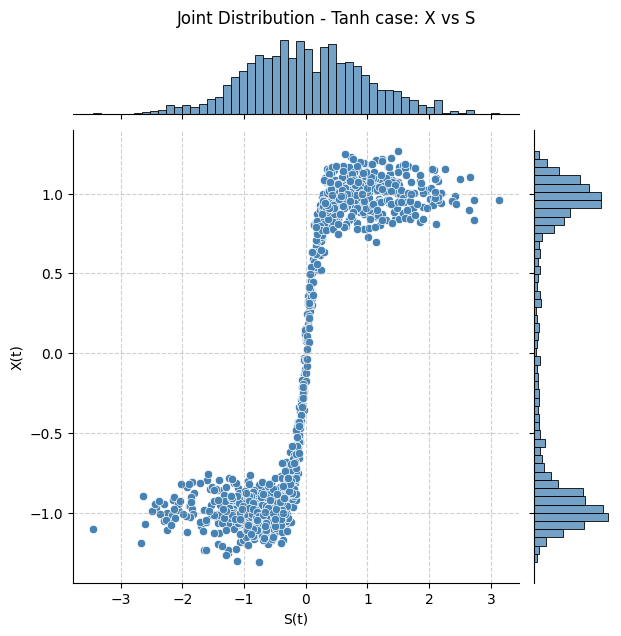

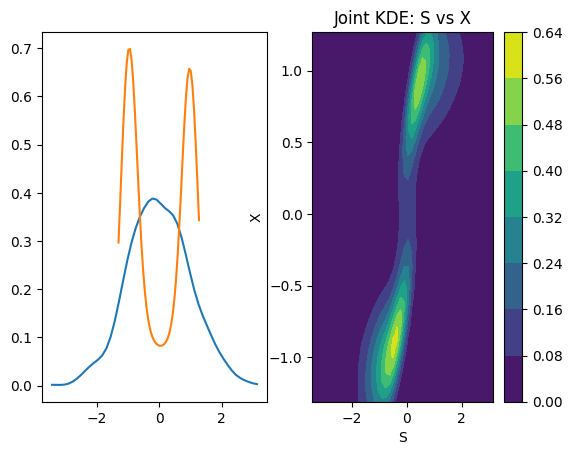

In [58]:
N = N_vec[-1]
data = nlib.generate_data(N, sigma_, f = f)


from scipy.stats import gaussian_kde
kde_s = gaussian_kde(data[:,0])
kde_x = gaussian_kde(data[:, 1])
kde_sx = gaussian_kde(data.T)


nlib.plot_joint_distribution_sns(data[:,0], data[:,1], title_string = "Tanh case: X vs S")

fig, axs = plt.subplots(nrows = 1, ncols = 2)
s_plot = np.linspace(np.min(data[:,0]), np.max(data[:, 0]))
x_plot = np.linspace(np.min(data[:,1]), np.max(data[:, 1]))

ax = axs[0]
ax.plot(s_plot, kde_s.pdf(s_plot))
ax.plot(x_plot, kde_x.pdf(x_plot))


ax = axs[1]


S, X = np.meshgrid(s_plot, x_plot)
positions = np.vstack([S.ravel(), X.ravel()])
Z = np.reshape(kde_sx(positions).T, S.shape)


ax = axs[1]
cf = ax.contourf(S, X, Z, cmap='viridis') # Using contourf for a filled contour plot
plt.colorbar(cf, ax=ax)                  # Add a colorbar to show density values

ax.set_xlabel('S')
ax.set_ylabel('X')
ax.set_title("Joint KDE: S vs X")

**Q:** why kde severely underestimates mi in this case? KDE underestimates mutual information in the tanh case due to oversmoothing induced by bandwidth selection. The nonlinear structure of the joint distribution is blurred, reducing the contrast between joint and marginal densities. As a result, the estimated dependence is systematically lower than the true value.

Study how MI estimate changes when you vary the KDE bandwidth.


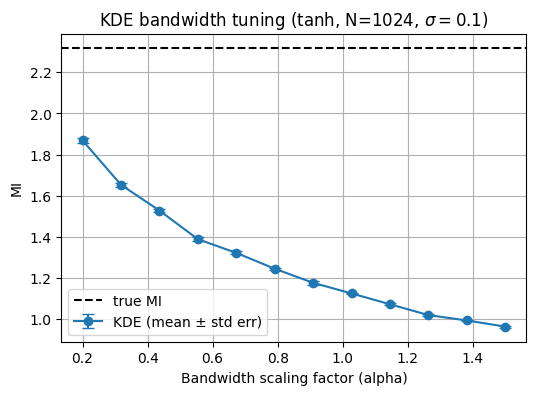

In [60]:
factors = np.linspace(0.2, 1.5, 12)

mi_estimates = np.zeros((len(factors), M))

for i, alpha in enumerate(factors):
    for m in range(M):
        data = nlib.generate_data(N, sigma_, f=f)
        mi_estimates[i, m] = nlib.estimate_mi(data, method="kde", alpha=alpha)

mean_mi = np.mean(mi_estimates, axis=1)
std_mi = np.std(mi_estimates, axis=1)
std_error = std_mi / np.sqrt(M)

plt.figure(figsize=(6,4))

plt.errorbar(factors, mean_mi, yerr=std_error, marker='o', capsize=4, label="KDE (mean ± std err)")

true_mi = nlib.mi_numeric(f, N_large=10000, sigma=sigma_)
plt.axhline(true_mi, linestyle='dashed', color='black', label='true MI')

plt.xlabel("Bandwidth scaling factor (alpha)")
plt.ylabel("MI")
plt.title(rf"KDE bandwidth tuning (tanh, N={N}, $\sigma={sigma_}$)")
plt.legend()
plt.grid()

plt.show()

Bandwidth tuning reveals a clear bias–variance trade-off: small bandwidths yield high-variance estimates, while large bandwidths produce smooth but biased estimates that underestimate mutual information.

---
## GAUSSIAN COPULA METHOD
Relies on the result
$$
mi(X:S) = - h(c)
$$
where c is the copula density function, and on the fact that $c$ is invariant under strictly monotonic transformations on both variables. 

**Input:** X, S two continuous random variables

**Algortihm:**

1. Compute the empiric marginal CDFs, $\hat{F}_S$ and $\hat{F}_X$
1. Transform each variable, independently, to a normal univariate gaussian

    $$
    S \rightarrow S' = \phi^{-1}(\hat{F}_S(S)) \\
    X \rightarrow X' = \phi^{-1}(\hat{F}_X(X)) \\
    $$
    $\phi^{-1}$: inverse cdf of a standard normal (mean $0$, std $1$).

2. Estimate $mi(X':S')$ assuming joint normality:

    $$
    mi(X':S') = - \frac{1}{2}\log_2(1 - \rho^2)
    $$

**Output:** $mi(X':S')= mi(X:S)$

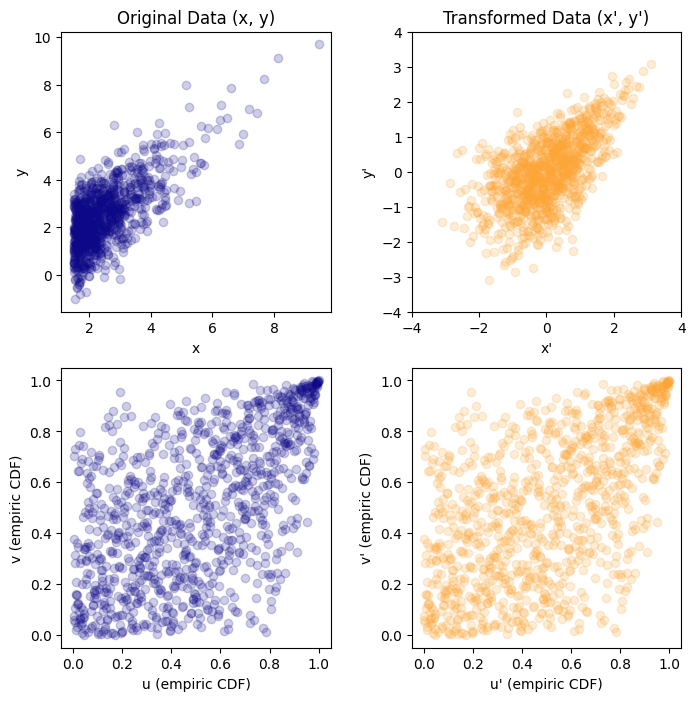

In [38]:
# Reproduction of the figures shown in the article

n = 1000
sigma_ = 1

x = scipy.stats.expon.rvs(1.5, size = n)
y = x + scipy.stats.norm.rvs(loc = 0, scale = sigma_, size = n)

data = np.vstack([x, y]).T

colors = cm.plasma(np.linspace(0, 0.8, 2))
color_dict = {
    "original": colors[0],
    "transformed": colors[1]
}


fig, axs = plt.subplots(nrows = 2, ncols = 2, figsize = (8,8))
axs = axs.flatten()

# ---------------------------
# -----Original Data --------
# ---------------------------
color = color_dict["original"]
axs[0].set_title("Original Data (x, y)")
axs[0].scatter(x, y, color = color, alpha = 0.2)
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")

cdfx = nlib.get_empiric_cdf(x)
cdfy = nlib.get_empiric_cdf(y)

u = cdfx(x)
v = cdfy(y)

axs[2].scatter(u, v, color = color, alpha = 0.2, label = "copula density")
axs[2].set_xlabel("u (empiric CDF)")
axs[2].set_ylabel("v (empiric CDF)")

# ---------------------------
# ---- Transformed Data -----
# ---------------------------

color = color_dict["transformed"]

eps = 1e-15 # cap to prevent infinities in xprime, yprime
xprime = scipy.stats.norm.ppf(np.clip(u, eps, 1 - eps)) # ppf= percent point function (inverse cdf)
yprime = scipy.stats.norm.ppf(np.clip(v, eps, 1 - eps))

axs[1].set_title("Transformed Data (x', y')")
axs[1].scatter(xprime, yprime,color = color, alpha = 0.2, label = "data")
axs[1].set_xlabel("x'")
axs[1].set_ylabel("y'")
axs[1].set_xlim(-4, +4)
axs[1].set_ylim(-4, +4)

cdfxprime = nlib.get_empiric_cdf(xprime)
cdfyprime = nlib.get_empiric_cdf(yprime)

uprime = cdfxprime(xprime)
vprime = cdfyprime(yprime)

axs[3].scatter(uprime, vprime, color = color, alpha = 0.2, label = "data")
axs[3].set_xlabel("u' (empiric CDF)")
axs[3].set_ylabel("v' (empiric CDF)")


plt.subplots_adjust(wspace = 0.3)

In [39]:
# ------------- true mi -----------------
N_large = 10000
y_large = scipy.stats.expon.rvs(1.5, size = N_large) + sigma_ * scipy.stats.norm.rvs(size = N_large)
true_hy = nlib.estimate_entropy_kde(y_large)
mi_true = true_hy - nlib.entropy_gaussian(sigma_)
print(f"True mi(x:y)= {mi_true}")
# ---------------------------------------


print(f"Estimated mi(x:y)= {nlib.estimate_mi(data, method = "gc")}")

True mi(x:y)= 0.437220618230147
Estimated mi(x:y)= 0.34811634544514347


In [40]:
N = 1000
sigma = 0.1
data = nlib.generate_data(N, sigma)

print(nlib.mi_gaussian_analytic(sigma**2))



dynamic_max = max(int(2 * np.sqrt(N)) , 50)
step = 2
bins = np.arange(10, dynamic_max, step)

print(nlib.estimate_mi(data, method='binning', bins = bins))
print(nlib.estimate_mi(data, method='kde'))
print(nlib.estimate_mi(data, method='gc'))
print(nlib.estimate_mi(data, method='gauss'))

3.3291057413758973
2.880374196275861
3.3183751644022763
3.2890238602450936
3.2861448472304935


## COMPARE ALL METHODS
Now we compare the different estimators with varying Channel noise $\sigma$ and number of samples $N$

First we do this for the simplest linear case.

In [66]:
sigma_vec = np.array([0.1, 0.2, 0.4, 0.6, 0.8, 1.])
N_vec = np.array([100, 200, 500, 1000, 2000, 5000])
M = 10

methods = ["binning", "kde", "gc", "gauss"]

results = {
    method: np.zeros((len(sigma_vec), len(N_vec), M))
    for method in methods
}

for i, sigma in enumerate(sigma_vec):
    for j, N in enumerate(N_vec):
        for k in range(M):
            data = nlib.generate_data(N, sigma)

            dynamic_max = max(int(2 * np.sqrt(N)), 50)
            bins = np.arange(10, dynamic_max, 2)

            results["binning"][i, j, k] = nlib.estimate_mi(data, "binning", bins=bins)
            results["kde"][i, j, k] = nlib.estimate_mi(data, "kde")
            results["gc"][i, j, k] = nlib.estimate_mi(data, "gc")
            results["gauss"][i, j, k] = nlib.estimate_mi(data, "gauss")

In [67]:
true_mi_vec = np.array([nlib.mi_gaussian_analytic(s**2) for s in sigma_vec])        #for linear case

In [68]:
mean_estimates = {m: np.mean(results[m], axis=2) for m in methods}
std_error = {
    m: np.std(results[m], axis=2) / np.sqrt(M)
    for m in methods
}

bias = {
    m: mean_estimates[m] - true_mi_vec[:, np.newaxis]
    for m in methods
}

variance = {
    m: np.var(results[m], axis=2)
    for m in methods
}

rel_error = {
    m: np.abs((mean_estimates[m] - true_mi_vec[:, np.newaxis]) / (true_mi_vec[:, np.newaxis]+1e-10))
    for m in methods
}

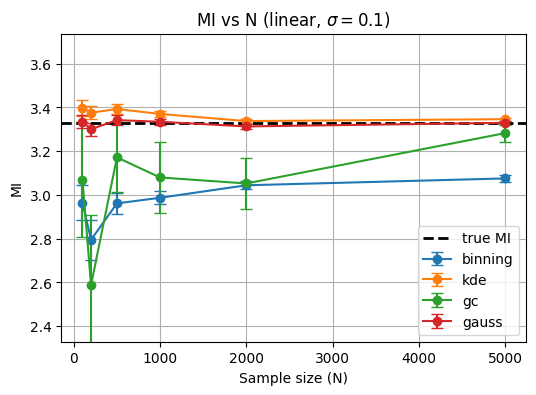

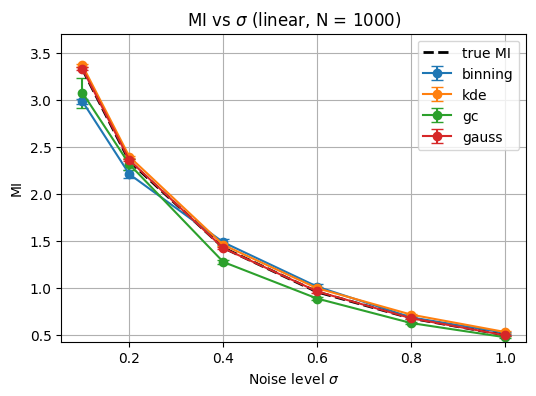

In [69]:
#fix sigma=0.1
i_sigma = list(sigma_vec).index(0.1)
sigma_fixed = sigma_vec[i_sigma]

true_mi_fixed = nlib.mi_gaussian_analytic(sigma_fixed**2)

plt.figure(figsize=(6,4))

for m in methods:
    plt.errorbar(
        N_vec,
        mean_estimates[m][i_sigma, :],
        yerr=std_error[m][i_sigma, :],
        marker='o',
        capsize=4,
        label=m
    )
plt.axhline(true_mi_fixed, color='black', linestyle='dashed', linewidth=2, label='true MI')

all_vals = np.concatenate([mean_estimates[m][i_sigma, :] for m in methods])
ymin = min(all_vals.min(), true_mi_fixed)
ymax = max(all_vals.max(), true_mi_fixed)
plt.ylim(ymin * 0.9, ymax * 1.1)

plt.xlabel("Sample size (N)")
plt.ylabel("MI")
plt.title(rf"MI vs N (linear, $\sigma = {sigma_fixed}$)")
plt.legend()
plt.grid()

plt.show()


#fix N=1000
j_N = list(N_vec).index(1000)
N_fixed = N_vec[j_N]

plt.figure(figsize=(6,4))

for m in methods:
    plt.errorbar(
        sigma_vec,
        mean_estimates[m][:, j_N],
        yerr=std_error[m][:, j_N],
        marker='o',
        capsize=4,
        label=m
    )
plt.plot(sigma_vec, true_mi_vec, color='black', linestyle='dashed', linewidth=2, label='true MI')

all_vals = np.concatenate([mean_estimates[m][:, j_N] for m in methods])
ymin = min(all_vals.min(), true_mi_vec.min())
ymax = max(all_vals.max(), true_mi_vec.max())
plt.ylim(ymin * 0.9, ymax * 1.1)

plt.xlabel(r"Noise level $\sigma$")
plt.ylabel("MI")
plt.title(rf"MI vs $\sigma$ (linear, N = {N_fixed})")
plt.legend()
plt.grid()

plt.show()

Is the estimator wrong because it’s biased or noisy? Plot bias vs variance and relative error

## THIS PART IS REDUNDANT??? WHAT DO YOU THINK?

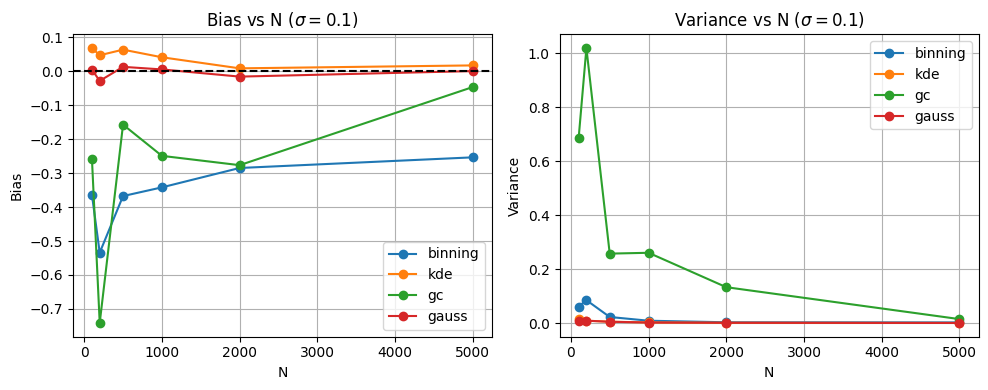

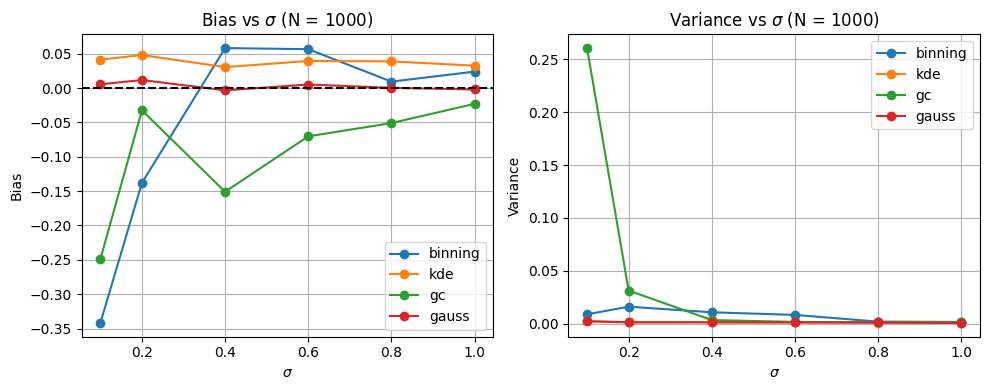

In [70]:
# FIXED SIGMA

fig, axs = plt.subplots(1, 2, figsize=(10,4))

# --- Bias ---
for m in methods:
    axs[0].plot(N_vec, bias[m][i_sigma, :], marker='o', label=m)

axs[0].axhline(0, color='black', linestyle='dashed')
axs[0].set_title(rf"Bias vs N ($\sigma = {sigma_vec[i_sigma]}$)")
axs[0].set_xlabel("N")
axs[0].set_ylabel("Bias")
axs[0].legend()
axs[0].grid()

# --- Variance ---
for m in methods:
    axs[1].plot(N_vec, variance[m][i_sigma, :], marker='o', label=m)

axs[1].set_title(rf"Variance vs N ($\sigma = {sigma_vec[i_sigma]}$)")
axs[1].set_xlabel("N")
axs[1].set_ylabel("Variance")
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()

# FIXED N

fig, axs = plt.subplots(1, 2, figsize=(10,4))

# --- Bias ---
for m in methods:
    axs[0].plot(sigma_vec, bias[m][:, j_N], marker='o', label=m)

axs[0].axhline(0, color='black', linestyle='dashed')
axs[0].set_title(rf"Bias vs $\sigma$ (N = {N_vec[j_N]})")
axs[0].set_xlabel(r"$\sigma$")
axs[0].set_ylabel("Bias")
axs[0].legend()
axs[0].grid()

# --- Variance ---
for m in methods:
    axs[1].plot(sigma_vec, variance[m][:, j_N], marker='o', label=m)

axs[1].set_title(rf"Variance vs $\sigma$ (N = {N_vec[j_N]})")
axs[1].set_xlabel(r"$\sigma$")
axs[1].set_ylabel("Variance")
axs[1].legend()
axs[1].grid()

plt.tight_layout()
plt.show()

C:\Users\angel\AppData\Local\Temp\ipykernel_19500\603244941.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


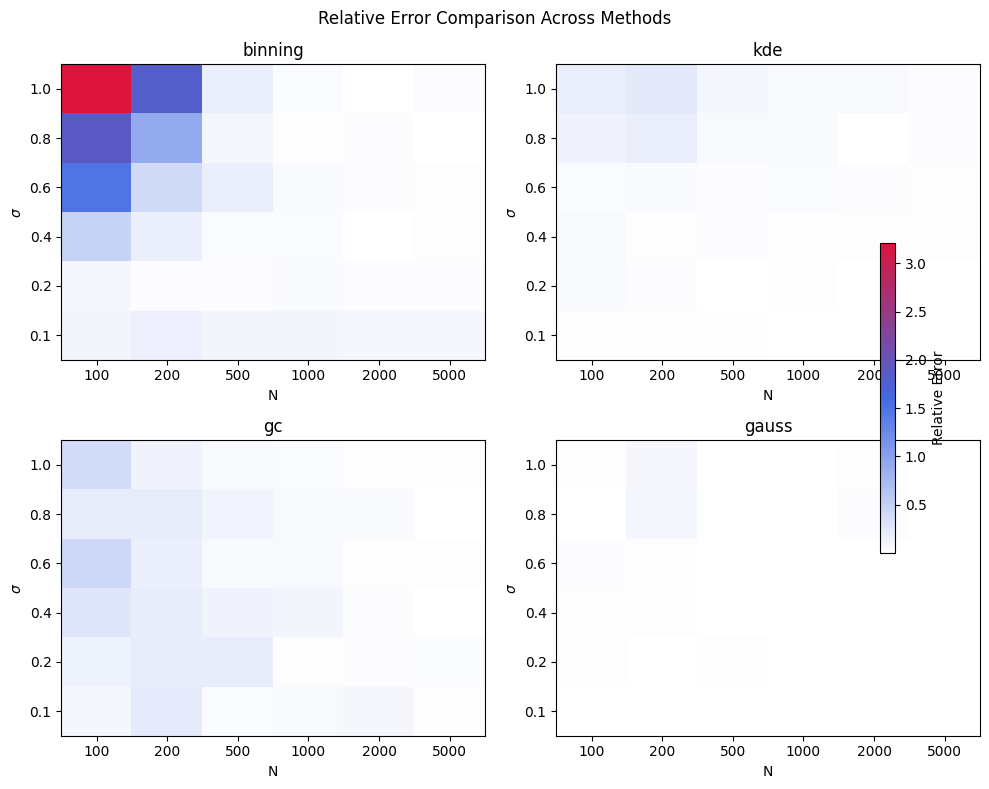

In [ ]:
vmin = min(rel_error[m].min() for m in methods)
vmax = max(rel_error[m].max() for m in methods)

fig, axs = plt.subplots(2, 2, figsize=(10,8))
axs = axs.flatten()

for idx, m in enumerate(methods):
    im = axs[idx].imshow(
        rel_error[m],
        origin="lower",
        aspect="auto",
        vmin=vmin,
        vmax=vmax,
        cmap=my_cmap
    )

    axs[idx].set_title(m)

    axs[idx].set_xticks(np.arange(len(N_vec)))
    axs[idx].set_xticklabels(N_vec)

    axs[idx].set_yticks(np.arange(len(sigma_vec)))
    axs[idx].set_yticklabels(sigma_vec)

    axs[idx].set_xlabel("Sample size (N)")
    axs[idx].set_ylabel(r"Noise level ($\sigma$)")

# --- ONE shared colorbar ---
cbar = fig.colorbar(im, ax=axs, orientation='vertical', fraction=0.02)
cbar.set_label("Relative Error")

plt.suptitle("Relative Error Comparison Across Methods")
#plt.tight_layout()

plt.show()

Now we try with different signal relationships $X=f(S)$

In [72]:
final_results = {}

for name, f in relations_dict.items():

    results = {m: np.zeros((len(sigma_vec), len(N_vec), M)) for m in methods}

    for i, sigma in enumerate(sigma_vec):
        for j, N in enumerate(N_vec):
            for k in range(M):

                data = nlib.generate_data(N, sigma, f=f)

                dynamic_max = max(int(2 * np.sqrt(N)), 50)
                bins = np.arange(10, dynamic_max, 2)

                results["binning"][i,j,k] = nlib.estimate_mi(data, "binning", bins=bins)
                results["kde"][i,j,k] = nlib.estimate_mi(data, "kde")
                results["gc"][i,j,k] = nlib.estimate_mi(data, "gc")
                results["gauss"][i,j,k] = nlib.estimate_mi(data, "gauss")

    final_results[name] = results

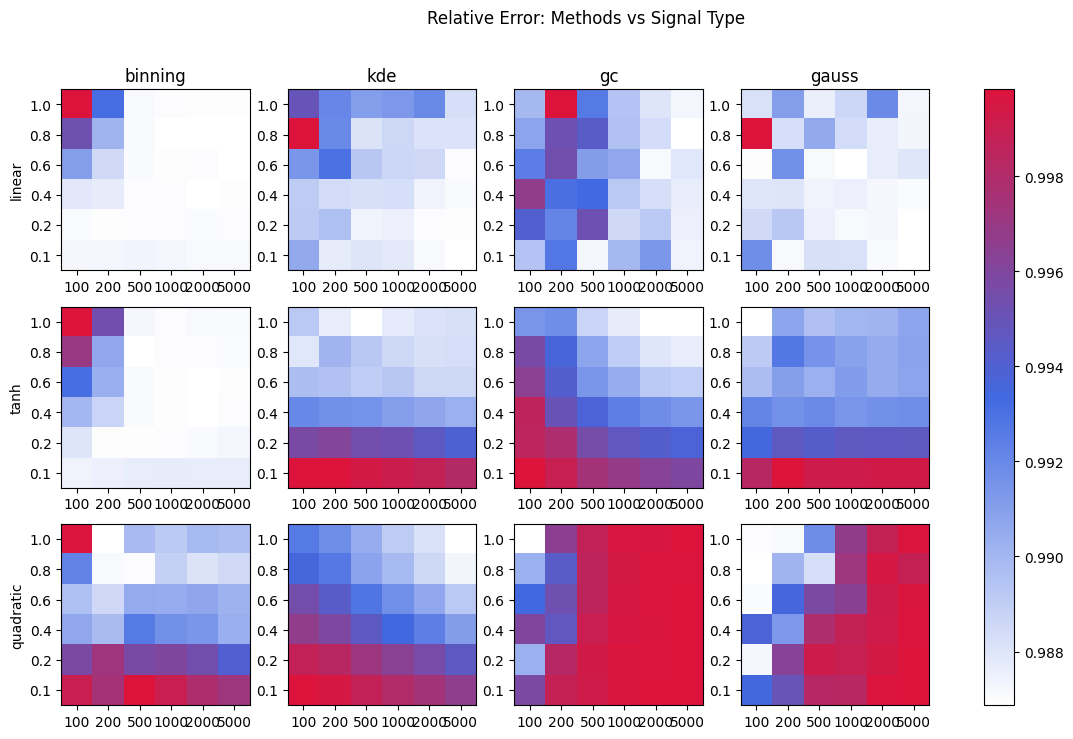

In [75]:
fig, axs = plt.subplots(len(relations_dict), len(methods), figsize=(14, 8))

for i, (name, results) in enumerate(final_results.items()):

    mean_est = {m: np.mean(results[m], axis=2) for m in methods}

    if name == "linear":
        true_mi_vec = np.array([nlib.mi_gaussian_analytic(s**2) for s in sigma_vec])
    else:
        true_mi_vec = np.array([nlib.mi_numeric(relations_dict[name], N_large=10000, sigma=s) for s in sigma_vec])

    for j, m in enumerate(methods):

        rel_error = np.abs((mean_est[m] - true_mi_vec[:, None]) / (true_mi_vec[:, None] + 1e-10))

        im = axs[i,j].imshow(rel_error, origin="lower", aspect="auto", cmap=my_cmap)

        if i == 0:
            axs[i,j].set_title(m)
        if j == 0:
            axs[i,j].set_ylabel(name)
        
        axs[i,j].set_xticks(np.arange(len(N_vec)))
        axs[i,j].set_xticklabels(N_vec)
        axs[i,j].set_yticks(np.arange(len(sigma_vec)))
        axs[i,j].set_yticklabels(sigma_vec)


# shared colorbar
fig.colorbar(im, ax=axs.ravel().tolist())

plt.suptitle("Relative Error: Methods vs Signal Type")
plt.show()